<a href="https://colab.research.google.com/github/azrapatvi/tesla-stock-price-forecasting/blob/main/tsla_stock_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tesla (TSLA) stock price prediction

importing libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from prophet import Prophet

In [ ]:
import plotly.io as pio
pio.renderers.default = "colab"

yahoo finance is a site to download time series data for stocks and cryptocurrencies

importing dataset

In [ ]:
import yfinance as yf
df=yf.download('TSLA',start='2025-03-18',end='2026-03-18')

/tmp/ipykernel_871/1605770177.py:2: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


In [ ]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2025-03-18,225.309998,230.100006,222.279999,228.160004,111477600
2025-03-19,235.860001,241.410004,229.199997,231.610001,111993800
2025-03-20,236.259995,238.000000,230.050003,233.350006,99028300
2025-03-21,248.710007,249.520004,234.550003,234.990005,132728700
2025-03-24,278.390015,278.640015,256.329987,258.079987,169079900


In [ ]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2026-03-11,407.820007,416.380005,402.149994,402.279999,62559900
2026-03-12,395.010010,406.500000,394.649994,405.179993,60973800
2026-03-13,391.200012,400.200012,389.950012,399.170013,58504100
2026-03-16,395.559998,403.730011,394.420013,396.220001,58068300
2026-03-17,399.269989,400.119995,393.000000,395.690002,46804000


In [ ]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
count,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,371.333825,378.492948,363.519761,370.899641,9.193301e+07
std,68.914206,69.330683,69.203102,69.863743,3.544376e+07
min,221.860001,230.100006,214.250000,223.779999,3.625290e+07
25%,319.660004,324.724991,313.949997,319.845001,6.646085e+07
50%,392.429993,400.119995,382.779999,390.049988,8.459520e+07
75%,432.209991,440.490005,425.260010,434.815002,1.060005e+08
max,489.880005,498.829987,485.329987,489.880005,2.874998e+08


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-03-18 to 2026-03-17
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   251 non-null    float64
 1   (High, TSLA)    251 non-null    float64
 2   (Low, TSLA)     251 non-null    float64
 3   (Open, TSLA)    251 non-null    float64
 4   (Volume, TSLA)  251 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


In [ ]:
px.area(df,x=df.index,y=df['Close'].squeeze())

In [ ]:
px.line(df, x=df.index, y=df['Close'].squeeze())

In [ ]:
px.area(df,x=df.index,y=df['Volume'].squeeze())

In [ ]:
px.bar(df,y=df['Volume'].squeeze())

In [ ]:
px.box(df,y=df['Volume'].squeeze())

Data Preparation

In [ ]:
df

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2025-03-18,225.309998,230.100006,222.279999,228.160004,111477600
2025-03-19,235.860001,241.410004,229.199997,231.610001,111993800
2025-03-20,236.259995,238.000000,230.050003,233.350006,99028300
2025-03-21,248.710007,249.520004,234.550003,234.990005,132728700
2025-03-24,278.390015,278.640015,256.329987,258.079987,169079900
...,...,...,...,...,...
2026-03-11,407.820007,416.380005,402.149994,402.279999,62559900
2026-03-12,395.010010,406.500000,394.649994,405.179993,60973800


In [ ]:
df = df.reset_index()

In [ ]:
df

Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2025-03-18,225.309998,230.100006,222.279999,228.160004,111477600
1,2025-03-19,235.860001,241.410004,229.199997,231.610001,111993800
2,2025-03-20,236.259995,238.000000,230.050003,233.350006,99028300
3,2025-03-21,248.710007,249.520004,234.550003,234.990005,132728700
4,2025-03-24,278.390015,278.640015,256.329987,258.079987,169079900
...,...,...,...,...,...,...
246,2026-03-11,407.820007,416.380005,402.149994,402.279999,62559900
247,2026-03-12,395.010010,406.500000,394.649994,405.179993,60973800
248,2026-03-13,391.200012,400.200012,389.950012,399.170013,58504100


In [ ]:
df.iloc[0]

,,0
Price,Ticker,
Date,,2025-03-18 00:00:00
Close,TSLA,225.309998
High,TSLA,230.100006
Low,TSLA,222.279999
Open,TSLA,228.160004
Volume,TSLA,111477600


In [ ]:
columns=['Date','Close']
columns

['Date', 'Close']

In [ ]:
ndf=df[columns]
ndf

Price,Date,Close
Ticker,,TSLA
0,2025-03-18,225.309998
1,2025-03-19,235.860001
2,2025-03-20,236.259995
3,2025-03-21,248.710007
4,2025-03-24,278.390015
...,...,...
246,2026-03-11,407.820007
247,2026-03-12,395.010010
248,2026-03-13,391.200012


In [ ]:
ndf.columns=['ds','y']
ndf

,ds,y
0,2025-03-18,225.309998
1,2025-03-19,235.860001
2,2025-03-20,236.259995
3,2025-03-21,248.710007
4,2025-03-24,278.390015
...,...,...
246,2026-03-11,407.820007
247,2026-03-12,395.010010
248,2026-03-13,391.200012
249,2026-03-16,395.559998


Creating Prophet Model

In [ ]:
model=Prophet()

model.fit(ndf)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future_dates=model.make_future_dataframe(periods=30)
future_dates

,ds
0,2025-03-18
1,2025-03-19
2,2025-03-20
3,2025-03-21
4,2025-03-24
...,...
276,2026-04-12
277,2026-04-13
278,2026-04-14
279,2026-04-15


In [ ]:
forecast=model.predict(future_dates)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-03-18,246.114500,221.198769,278.392899,246.114500,246.114500,4.101828,4.101828,4.101828,4.101828,4.101828,4.101828,0.0,0.0,0.0,250.216328
1,2025-03-19,246.941048,222.475049,282.583997,246.941048,246.941048,6.384682,6.384682,6.384682,6.384682,6.384682,6.384682,0.0,0.0,0.0,253.325730
2,2025-03-20,247.767596,221.327031,278.029269,247.767596,247.767596,0.850804,0.850804,0.850804,0.850804,0.850804,0.850804,0.0,0.0,0.0,248.618400
3,2025-03-21,248.594144,225.342232,279.636822,248.594144,248.594144,3.947525,3.947525,3.947525,3.947525,3.947525,3.947525,0.0,0.0,0.0,252.541669
4,2025-03-24,251.073789,226.364616,286.795199,251.073789,251.073789,5.992282,5.992282,5.992282,5.992282,5.992282,5.992282,0.0,0.0,0.0,257.066071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,2026-04-12,379.398037,340.029350,399.559151,375.874375,383.211979,-10.638561,-10.638561,-10.638561,-10.638561,-10.638561,-10.638561,0.0,0.0,0.0,368.759476
277,2026-04-13,378.788850,355.903271,413.886505,375.012666,382.840476,5.992282,5.992282,5.992282,5.992282,5.992282,5.992282,0.0,0.0,0.0,384.781132
278,2026-04-14,378.179663,353.523372,413.125893,374.114481,382.480426,4.101828,4.101828,4.101828,4.101828,4.101828,4.101828,0.0,0.0,0.0,382.281491
279,2026-04-15,377.570476,355.821516,413.098047,373.235584,382.104513,6.384682,6.384682,6.384682,6.384682,6.384682,6.384682,0.0,0.0,0.0,383.955158


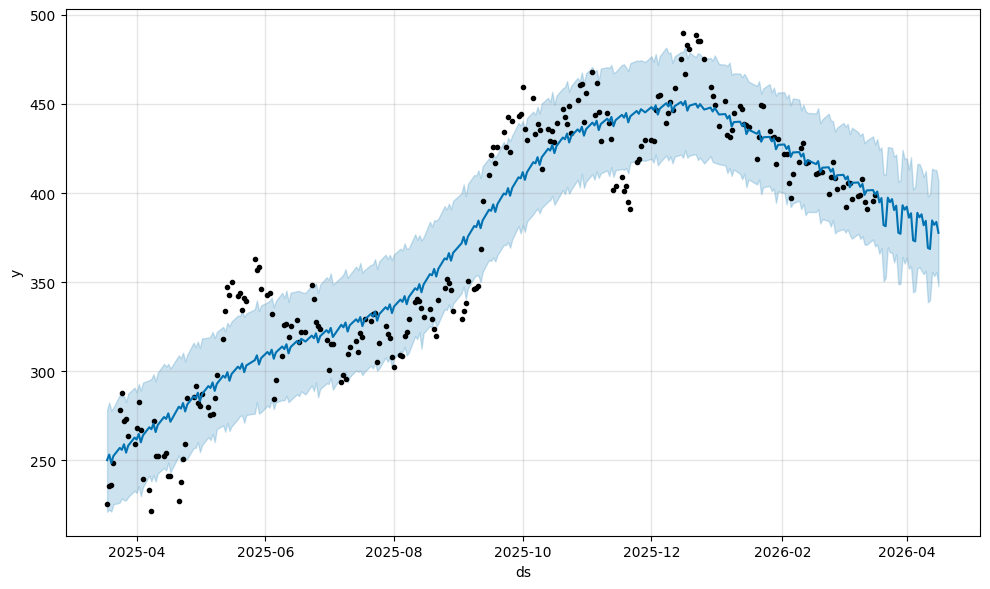

In [ ]:
fig=model.plot(forecast)
plt.show()

In [ ]:
px.line(forecast,x=forecast['ds'],y=forecast['yhat'])

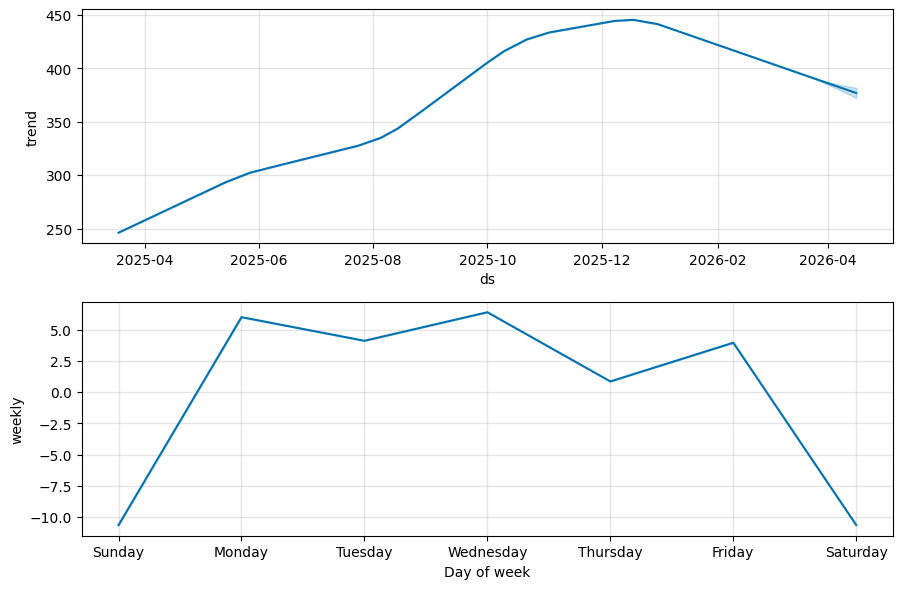

In [ ]:
fig=model.plot_components(forecast)
plt.show()

In [ ]:
forecast.to_csv('forecast.csv')